In [1]:
import sys
from os import path, getcwd
import pathlib

# where everything is stored (data and code)
ROOT = pathlib.Path(getcwd()).parent.absolute()
# code paths
sys.path.append(path.join(ROOT, 'src/models'))
sys.path.append(path.join(ROOT, 'src/exp'))
sys.path.append(path.join(ROOT, 'src/common'))

In [2]:
from scipy.stats import norm, vonmises, special_ortho_group, multivariate_normal, uniform, chi2
from math import sqrt
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import figure
import numpy as np
import torch
from collections.abc import Iterable
from scipy.stats import uniform
from scipy.special import erf
import warnings

from precomputation.initialization import *
from misc.common_functions import load_config
from inflation.jupyter_helper import *

warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
%reload_ext autoreload
%autoreload 2
from master.data.line_data import LineData
from master.data.gauss_data import GaussData
from master.data.smoothstep_data import SmoothstepData


-----------

# One weird function
Y, X ~ N
What is Y+X^2

In [6]:
from scipy.special import yv as bessel_2nd
from scipy.stats import chi2

(0.0, 3.0)

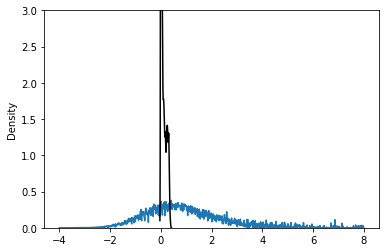

In [8]:
def weird_pdf_2(z):
    a = 1 - 2. * z
    return 1/(2 * np.pi) * np.exp(-1/2 * z**2) * \
    1/2 * np.exp(1/16 * a**2) * np.sqrt(a) * bessel_2nd(1./4, 1./16 * a**2)

#weird_pdf(10)
def weird_pdf(z):
    sample_size = 10000
    rvs = chi2.rvs(df=1, size=sample_size).repeat(len(z)).reshape(len(z), sample_size).T
    #print(rvs.shape)
    return norm.pdf(z - rvs).mean(0)
    
x = np.linspace(-4, 8, 1000)
#print("weird shape", weird_pdf(x).shape)
pds = weird_pdf(x)
plt.plot(x, pds, label=f'')

sns.distplot(pds, label='State Dens', color='k', hist=False, kde_kws={'bw_adjust': 0.5}, kde=True, bins=100) # kde_kws={'cumulative':True})
plt.ylim(top=3)

In [9]:
X,Y = norm.rvs(size=(2, 1000))

def f(X):
    return X**2

X_2 = X + (Y + f(X))

A = norm.pdf(x=X_2, loc=Y + f(X))
B = weird_pdf(Y + f(X))

#sns.distplot(A*B, label='State Dens', color='k', hist=False, kde_kws={'bw_adjust': 0.5}, kde=True, bins=100) # kde_kws={'cumulative':True})

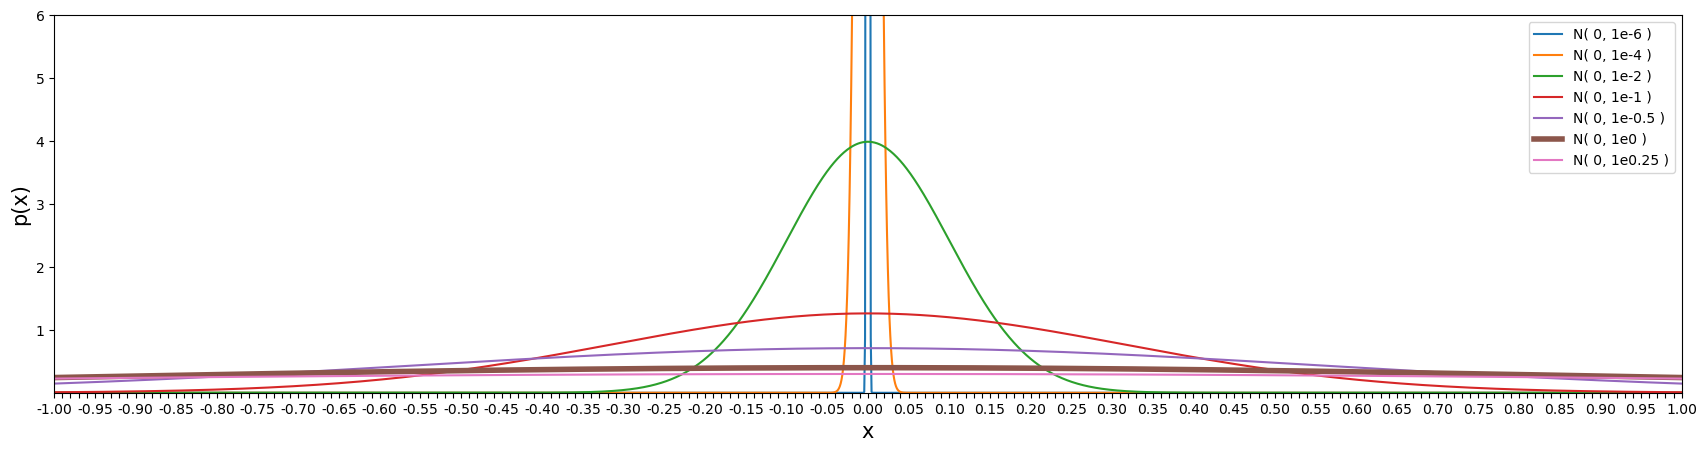

In [119]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(21, 5), squeeze=True, dpi=100)

lims = 1
z = np.linspace(-lims, lims, 2000)

ALL_LOG_VARIANCES = [-6, -4, -2, -1, -0.5, 0, 0.25]

for var in ALL_LOG_VARIANCES:
    pds = norm.pdf(z, scale=np.sqrt(10**var))
    linewidth = 4 if var == 0 else 1.5
        
    ax.plot(z, pds, '-', label=f'N( 0, 1e{var} )', linewidth=linewidth)
ax.set_ylim([0.001, 6])
ax.set_xlim([-lims, lims])
start, end = ax.get_xlim()

steps = 0.01
tick_positions = np.arange(start, end+steps, steps)
tick_lables = [f'{tick:.2f}' if i % 5 == 0 else '' for i, tick in enumerate(tick_positions)]
    
ax.set_xlabel('x', size=15)
ax.set_ylabel('p(x)', size=15)
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_lables)
ax.legend()
_=_

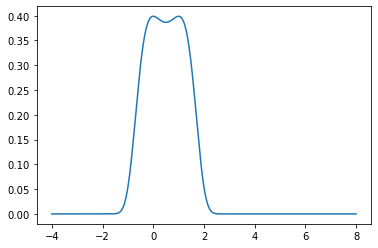

In [10]:
X = norm.rvs(size=(1000))

y = 0

X_2 = norm.pdf(X, loc=y + X**2)

x = np.linspace(-4, 8, 1000)
plt.plot(x, norm.pdf(x, loc=y + x**2))

True Dens State

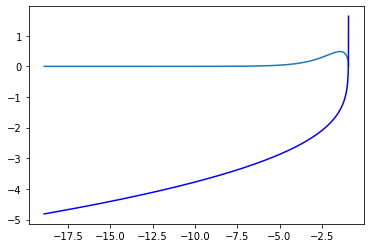

In [25]:
x = np.linspace(0, 6, 1000)
log_pd = norm.logpdf(x)

y = x * 2 * norm.pdf(x)
plt.plot(log_pd, y, '-', label='Gauss')

plt.plot(log_pd, chi2.logpdf(df=1, x=x), '-', color='b', label='CHI')

-----------

In [31]:
def multivariate_normal_log(x, cov):
    # assume 2D and mean=0
    # copied from scipy:
    dev = x
    ((left_top, right_top),
    (left_bottom, right_bottom)) = cov
    det = left_top*right_bottom - left_bottom*right_top
    log_det_cov = np.log(det)
    rank = 2
    
    inv_cov_matrix = 1/ det * np.array([[right_bottom, -right_top], [- left_bottom, left_top]])
    #maha = np.sum(np.square(np.dot(dev, prec_U)), axis=-1)
    maha = -0.5 * (x.T @ inv_cov_matrix @ x )
    return -0.5 * (rank * np.log(2*np.pi) + log_det_cov)

def dens_state_multi_norm_2(cov, label=None):
    # apparently sampling works fine
    x = multivariate_normal.rvs(size=10000, cov=cov)
    #pds = multivariate_normal_log(x, cov=cov)
    
    if label is None:
        label = f'N(0, {cov})'
    label += f' Mean: {pds.mean():.2f}'
    
    #sns.distplot(pds, label=label, hist=False, kde_kws={'bw_adjust': 0.5}, kde=True, bins=100) # kde_kws={'cumulative':True})


[[22500.06125625, 22500.06290625], [22500.06290625, 22500.064600694444]]
Det: 0.999999880790710449218750000000
Det of transformation 0.000000000000000000000000000000
150.0 0.2475 150.0 0.25416666666666665
----------
[[1406.2528667100694, 1406.2542944878471], [1406.2542944878471, 1406.2564333767361]]
Det: 1.000000000232830643653869628906
Det of transformation 0.000000000000000000000000000000
37.5 0.05354166666666667 37.5 0.08020833333333334
----------


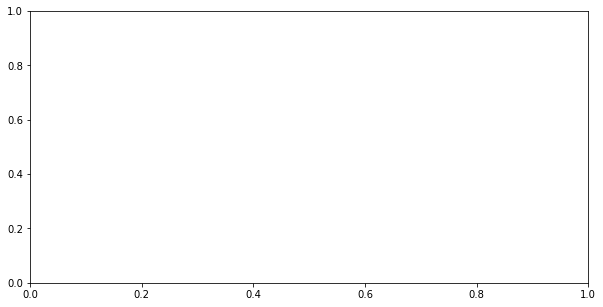

In [31]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), squeeze=True)

teste nochmal die determinante der cov matrix von den normal verteilungen

M = 600
size = 10000
dens_state_multi_norm(np.eye(2), label='2D Gauss', size=size)
#dens_state_multi_norm(np.eye(2), label='2D Gauss')
dens_state_multi_norm(create_cov_matrix(M/4, (M-6)/(4*M), M/4, (M+10)/(4*M)), label='[A/4, A/4]')
dens_state_multi_norm(create_cov_matrix(M/16, (M-86)/(16*M), M/16, (M+170)/(16*M)), label='[A/16, A/16]')
#plt.legend()

[[122503.0406640625, 105002.611265625], [105002.611265625, 90002.24250625]]
Det: 1.000000000000000000000000000000


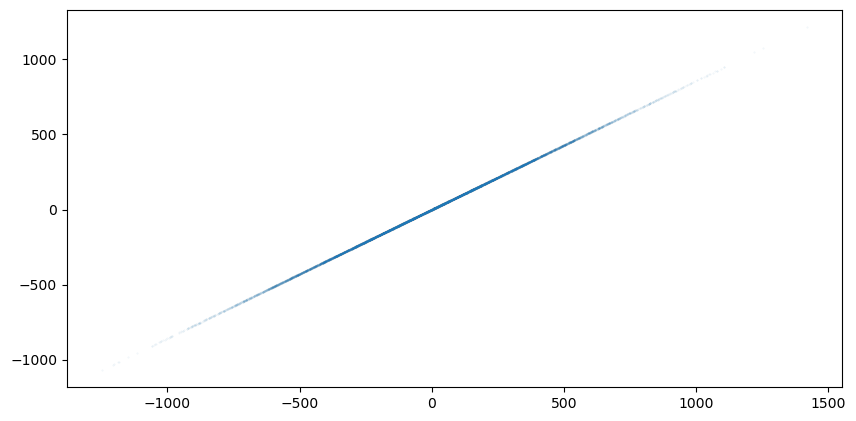

In [117]:
x = multivariate_normal.rvs(size=10000, cov=create_cov_matrix(7/4*M, (-5/(4*M)+7/4), 3/2 * M, (-1/(2*M) + 3/2)))

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), squeeze=True, dpi=100)

plt.scatter(x.T[0], x.T[1], s=0.1, alpha=0.1)
#sns.regplot(x.T[0], x.T[1])
#plt.plot( 'x', 'y', "", data=x.T, linestyle='', marker='o', markersize=0.7)
#x.T.shape

----------

In [27]:
def approx_density(A, B):
    bin_count = 300
    alpha = 0.005
    histo_density, x_edges, y_edges = np.histogram2d(A, B, range=[quantile_finder(A, alpha), quantile_finder(B, alpha)], 
                                                     bins=bin_count, density=True)

    all_masses = []
    cumulative_masses = []
    cumulative_mass = 0
    for x in range(bin_count):
        x_len = x_edges[x+1] - x_edges[x] 
        for y in range(bin_count):
            y_len = y_edges[y+1] - y_edges[y]

            cell_mass = histo_density[x,y] * x_len * y_len
            cumulative_mass += cell_mass

            cumulative_masses.append(cumulative_mass)
            all_masses.append(histo_density[x,y])

    print('Total Mass:', cumulative_mass)
    cumulative_masses = np.array(cumulative_masses)
    all_masses = np.log(np.array(all_masses))
    #all_masses = np.array(all_masses)

    likelihood_samples = []
    sample_count = 100000
    for sample in uniform.rvs(size=sample_count):
        hitted_cell = sample < cumulative_masses 

        # will stop at first True
        idx = np.argmax(hitted_cell)
        likelihood_samples.append(all_masses[idx])

    fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(20, 10), squeeze=True)
    sns.distplot(likelihood_samples, ax=axs[0], label='Strange Distribution', color='tab:olive', hist=True, 
                 bins=100, kde_kws={'bw_adjust': 0.5}, kde=True)
    #uni_samples >= np.tile(cumulative_mass, (sample_count, 1))
    dens_state_multi_norm(np.eye(2), ax=axs[0], log=True)

    axs[0].legend()

    sns.heatmap(histo_density, ax=axs[1])
    return fig

Total Mass: 1.0000000000000886


<ipython-input-24-a4c8da7f18a4>:23: RuntimeWarning: divide by zero encountered in log
  all_masses = np.log(np.array(all_masses))


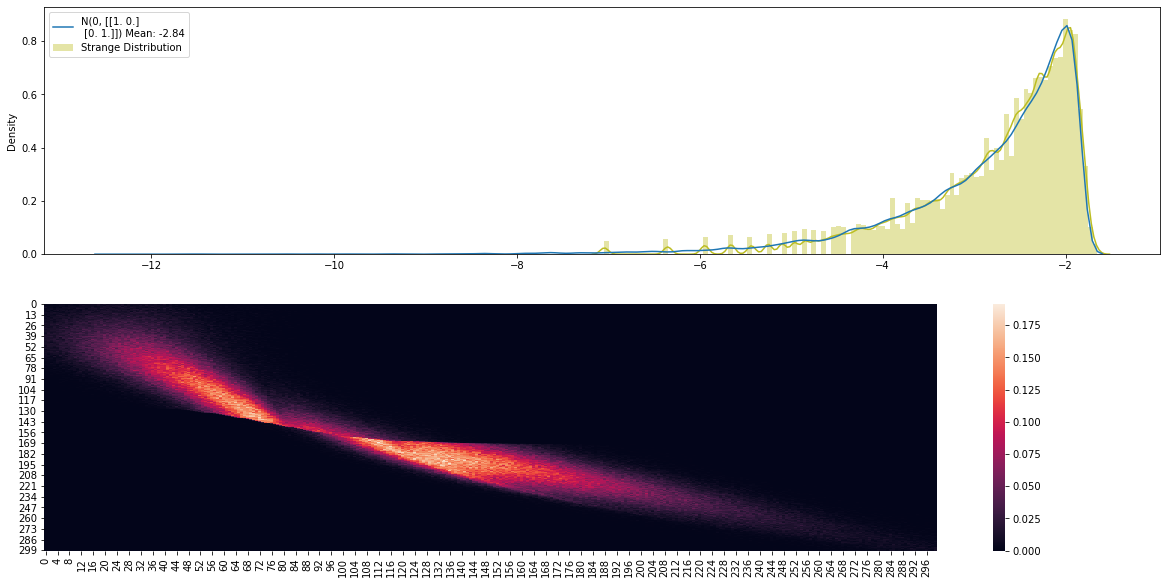

In [25]:
def random_distribution():
    X,Y = norm.rvs(size=(2, 1000000))

    A_1 = X
    B_1 = Y

    A_2 = A_1
    B_2 = B_1 + 2 * np.sin(A_1)

    A_3 = A_2 + 1/(np.abs(B_2) + 1) # np.cos(B_2)
    B_3 = B_2

    A_4 = A_3
    B_4 = B_3
    conditioned = A_3 > 0.5
    B_4[conditioned] += A_3[conditioned] ** 2 + 2
    conditioned = np.logical_not(conditioned)
    B_4[conditioned] += A_3[conditioned] / 2
    
    A_5 = A_4 + 1/(1 + np.exp(-B_4))
    B_5 = B_4

    return A_5, B_5

A, B = random_distribution()
    
fig = approx_density(A, B)

fig.savefig(f'random/weird distribution.png')

Total Mass: 1.0000000000000118


<ipython-input-27-a4c8da7f18a4>:23: RuntimeWarning: divide by zero encountered in log
  all_masses = np.log(np.array(all_masses))


NameError: name 'dens_state_multi_norm' is not defined

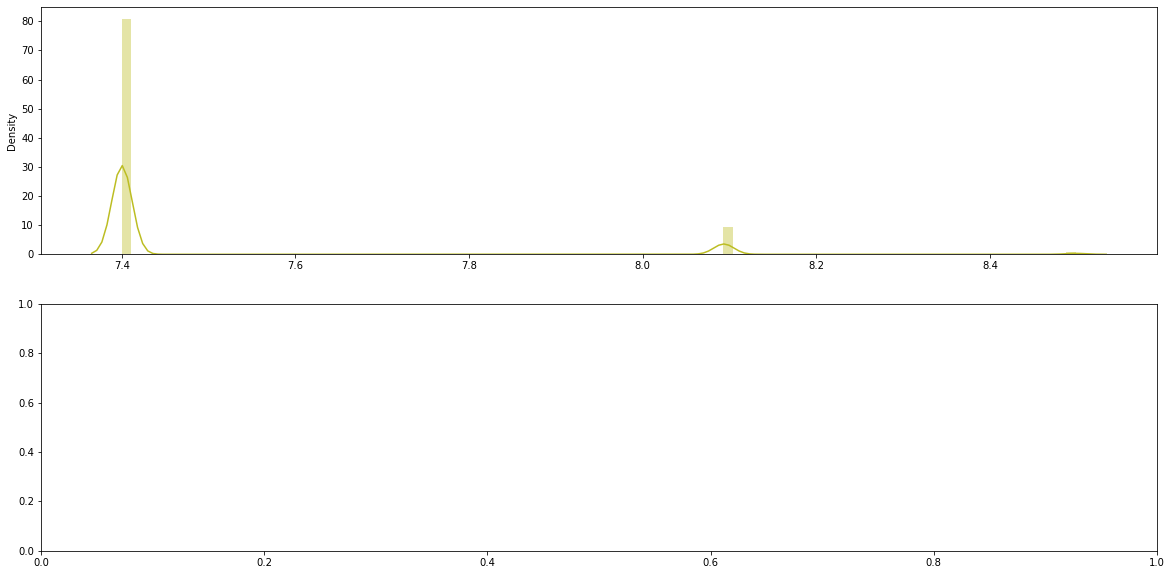

In [149]:
e = 1
for _ in range(50):
    e = 0.5*e + 1
    #print(e)

In [26]:
import numpy as np

def create_cov_matrix(a, b, c, d):
    # X, Y ~ N
    # aX + bY
    # cX + dY
    # returns cov matrix of this distribution
    a = np.double(a)
    b = np.double(b)
    c = np.double(c)
    d = np.double(d)

    left_top = a ** 2 + b ** 2
    left_bottom = right_top = a * c + d * b
    right_bottom = c ** 2 + d ** 2

    cov = [[left_top, right_top],
           [left_bottom, right_bottom]]
    #print(cov)
    print(f'Det: {left_top * right_bottom - left_bottom * right_top:.30f}')
    #print(f'Det of transformation {a * d - c * d:.30f}')
    print(a, b, c, d)
    #print('----------')
    return np.array(cov)


def print_stuff(_x_1, _y_1, _y_1_m, _x_2, _y_2, _y_2_m):
    print(f'2^{np.log2(_x_1)} m x + 2^{np.log2(_y_1)} y + {_y_1_m:.15f} y /m')
    print(f'2^{np.log2(_x_2)} m x + 2^{np.log2(_y_2)} y + {_y_2_m:.15f} y /m')
    #print(f'1/{1/x_1} m x + y( 1/{1/y_1} + {y_1_m}/m )')
    #print(f'1/{1/x_2} m x + y( 1/{1/y_2} + {y_2_m}/m )')
    a = _x_1 * _y_2_m - _x_2 * _y_1_m
    b = _x_1 * _y_2 - _x_2 * _y_1
    print(f'Det: {a} | m: {b}')
    if a != 1 or b != 0:
        print('wooooooooot')

    #### the according Normal distribution
    M = 10
    a = _x_1
    b = _y_1 + _y_1_m/M
    c = _x_2
    d = _y_2 + _y_2_m/M

    create_cov_matrix(a,b,c,d)
    print('---------')
"""
x_1 m x + y_1 y + y_1_m y /m
x_2 m x + y_2 y + y_2_m y /m
"""

x_1 = 1
y_1 = 1
y_1_m = -1

x_2 = 1
y_2 = 1
y_2_m = 0

print_stuff(x_1, y_1, y_1_m, x_2, y_2, y_2_m)
print('----------')
for _ in range(10):
    # top - bottom half
    x_1 -= x_2 / 2
    y_1 -= y_2 / 2
    y_1_m -= y_2_m / 2

    print_stuff(x_1, y_1, y_1_m, x_2, y_2, y_2_m)
    # bottom - top
    x_2 -= x_1
    y_2 -= y_1
    y_2_m -= y_1_m

    print_stuff(x_1, y_1, y_1_m, x_2, y_2, y_2_m)
    print('---------')

2^-50.0*mX + -375299968947541.37500/M Y + 2^-50.0Y
2^-50.0*mX + 750599937895082.75000/MY + 2^-50.0Y
[[1.4085006669202552e+29, -2.8170013338405103e+29], [-2.8170013338405103e+29, 5.634002667681021e+29]]
Det: 0.000000000000000000000000000000
Det of transformation 0.000000000000000000000000000000
8.881784197001252e-16 -375299968947541.4 8.881784197001252e-16 750599937895082.8
----------


1.0

In [22]:
375299968947541.375*2

750599937895082.8

----------

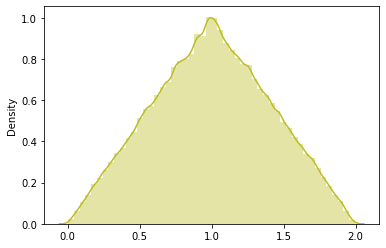

In [10]:
X, Y = uniform.rvs(size=(2, 100000))
M = 1
Z = Y + M * X

# [X, Y]

_=sns.distplot(Z, label='Y + M * X', color='tab:olive', hist=True, kde_kws={'bw_adjust': 0.5}, kde=True)

---------

--------

--------

In [26]:
def smoothing(x, f):
    res = np.ones_like(x) * -1
    res[x <= 0] = 0
    res[x >= 1] = 1
    
    between_0_1 = np.logical_and(x > 0, x < 1)
    res[between_0_1] = f(x[between_0_1])
    return res

def smooth3(x):
    return smoothing(x, lambda x: 6 * x**5 - 15 * x**4 + 10 * x**3)

def s1(x):
    return smoothing(x, lambda x: 3 * x**2 - 2 * x ** 3)


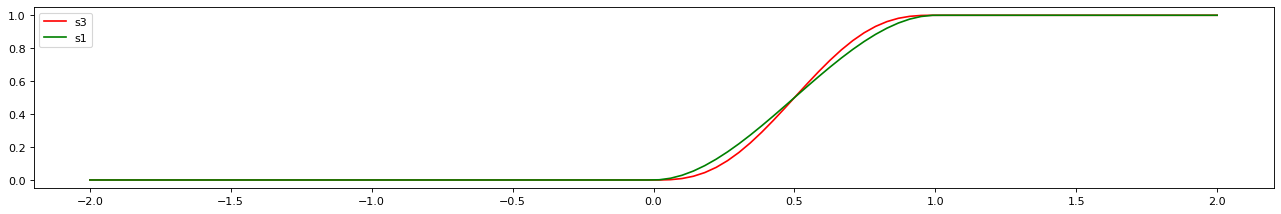

In [27]:
fig = plt.figure(figsize=(20, 3), dpi=80)

x = np.linspace(-2, 2, 100)
plt.plot(x, smooth3(x), color='r', label='s3')
plt.plot(x, s1(x), color='g', label='s1')
#plt.ylim([-2, 2])
_=plt.legend()

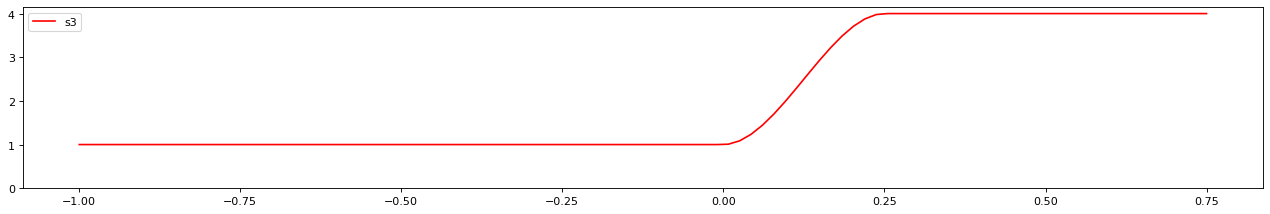

In [28]:
fig = plt.figure(figsize=(20, 3), dpi=80)

x = np.linspace(-1, 0.75, 100)
plt.plot(x, 3*s1(4*x) + 1, color='r', label='s3')
plt.ylim(bottom=0)
_=plt.legend()

(10000,)


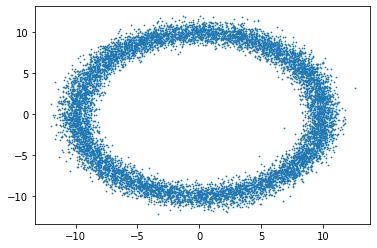

In [9]:
Z = multivariate_normal.rvs(cov=np.eye(100), size=10000)
length = np.linalg.norm(Z, axis=1)

angles = [np.arctan(Z[:, i] / Z[:, i+1]) for i in range(1)]
#angles = np.array(angles).T
#angles[Z[:, 1] < 0]
#
angles = np.array(angles).T * 2
sin = np.mean(np.sin(angles), axis=1)
cos = np.mean(np.cos(angles), axis=1)
average_angles = np.mean(angles, axis=1) #np.arctan2(sin, cos)
print(length.shape)

X = length * np.cos(average_angles)
Y = length * np.sin(average_angles)
    
plt.scatter(X, Y, s=3, cmap='magma', linewidths=0)

(10000, 99)
(10000,)


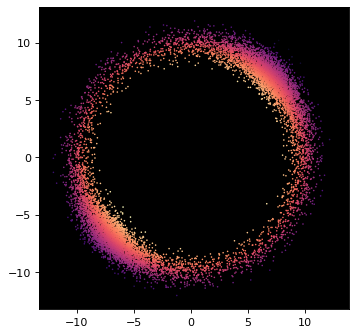

In [21]:
Z = multivariate_normal.rvs(cov=np.eye(100), size=10000)
c = multivariate_normal.logpdf(Z, cov=np.eye(100))
length = np.linalg.norm(Z, axis=1)

#ancat = Z[:, 0]  # x
#cat = Z[:, 1]  # y
#angles = np.arctan2(cat / (length + ancat)) * 2

angles = [np.arctan2(Z[:, i], Z[:, i+1]) for i in range(100-1)]
angles = np.array(angles).T
print(angles.shape)
#angles = np.arctan2(cat, ancat)
sin = np.mean(np.sin(angles), axis=1)
cos = np.mean(np.cos(angles), axis=1)
angles = np.arctan2(sin, cos)
print(angles.shape)
X = length * np.cos(angles)
Y = length * np.sin(angles)
    
    
fig, ax = plt.subplots(figsize=(5, 5), dpi=80)
ax.scatter(X, Y, c=c, s=2, cmap='magma', linewidths=0)
ax.patch.set_facecolor('black')
ax.axis('equal')
_=_

In [25]:
print(norm.pdf(0.3))
jacobian = 4
print(norm.pdf(0.3*jacobian) * jacobian)

0.38138781546052414
0.7767442199328519


-----------
# Mises in High Dim

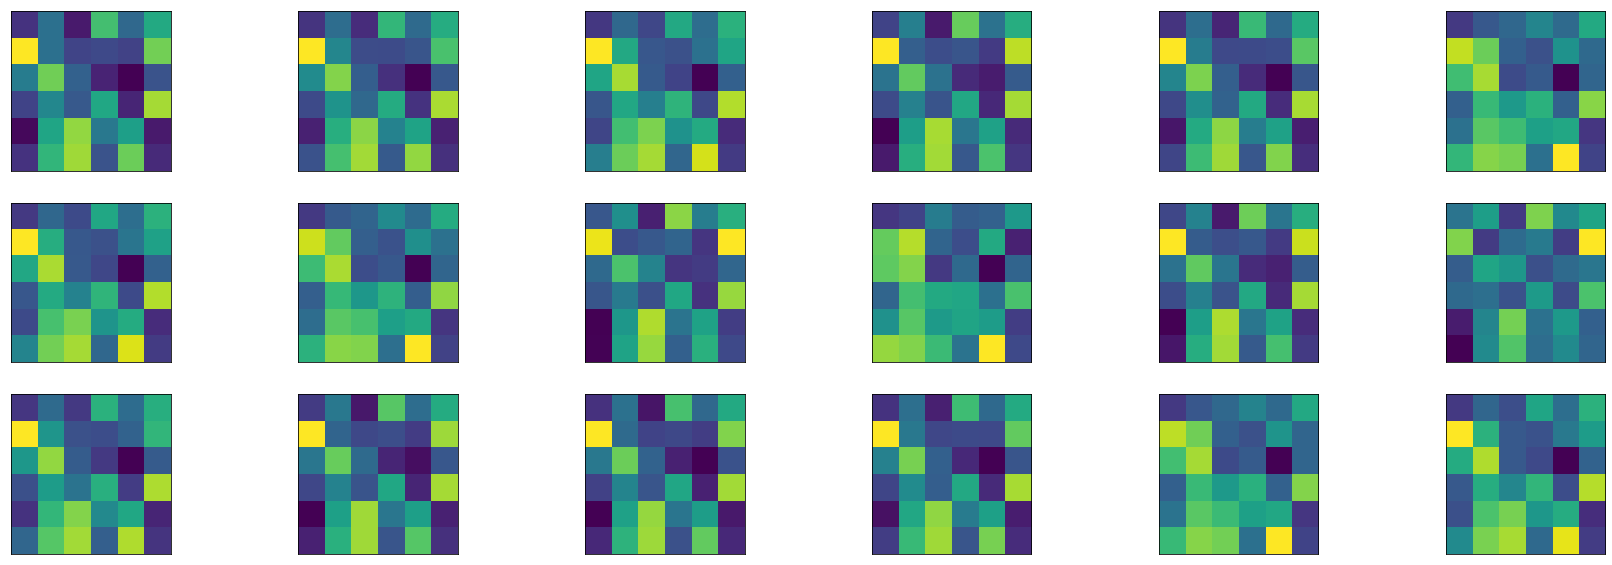

In [29]:
target_dim_width = 6
rotation_matrix = special_ortho_group.rvs(target_dim_width**2)
def create_high_dim_mises(sample_count):
    
    images = []
    for _ in range(sample_count):
        x_1 = vonmises.rvs(kappa=6)
        x_2 = target_dim_width* np.cos(x_1), target_dim_width* np.sin(x_1)
        
        flat_embedding = np.zeros(target_dim_width**2)
        flat_embedding[0:2] = x_2

        # orthogonal matirx => side irrelevant
        rotated_embedding = rotation_matrix @ flat_embedding
        image = rotated_embedding.reshape((target_dim_width, target_dim_width))
        images.append(image)
        
    return images

sample_count = 18
images = create_high_dim_mises(sample_count)

fig, axs = plt.subplots(nrows=3, ncols=6, squeeze=False, figsize=(30, 10))
axs = axs.flatten()
for img, ax in zip(images, axs):
    ax.matshow(img)
    ax.set_xticks([]), ax.set_yticks([])